# Data Exploration with one sample only

## Load data

In [3]:
import rasterio
import matplotlib.pyplot as plt

# Paths to your two imagees
cloudy_path = r"E:\Rasengan\Cloud-Removal\data\cloudy\nzb1\BAND2.tif"
clear_path  = r"E:\Rasengan\Cloud-Removal\data\non-cloudy\nzb1\BAND2.tif"

# Load cloudy image
with rasterio.open(cloudy_path) as src:
    cloudy = src.read()
    cloudy_meta = src.meta

# Load non-cloudy image
with rasterio.open(clear_path) as src:
    clear = src.read()
    clear_meta = src.meta

## Metadata

In [4]:
print("Cloud Image metadata")

for key,value in cloudy_meta.items():
    print(f"{key}: {value}")

Cloud Image metadata
driver: GTiff
dtype: uint16
nodata: None
width: 18130
height: 16177
count: 1
crs: PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32644"]]
transform: | 5.00, 0.00, 219203.94|
| 0.00,-5.00, 2126272.50|
| 0.00, 0.00, 1.00|


In [5]:
print("Non - Cloud Image metadata")

for key,value in clear_meta.items():
    print(f"{key}: {value}")

Non - Cloud Image metadata
driver: GTiff
dtype: uint16
nodata: None
width: 18097
height: 16199
count: 1
crs: PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32644"]]
transform: | 5.00, 0.00, 219198.94|
| 0.00,-5.00, 2126517.50|
| 0.00, 0.00, 1.00|


## Image Dimensions

In [7]:
print("Cloudy Image: ")
print(f"Width: {cloudy.shape[2]} pixels")
print(f"Height: {cloudy.shape[1]} pixels")

print("\nCloudy Image: ")
print(f"Width: {clear.shape[2]} pixels")
print(f"Height: {clear.shape[1]} pixels")

print("Difference: ")
print(f"Width: {abs(cloudy.shape[2]-clear.shape[2])} pixels")
print(f"Height: {abs(cloudy.shape[1]-clear.shape[1])} pixels")


Cloudy Image: 
Width: 18130 pixels
Height: 16177 pixels

Cloudy Image: 
Width: 18097 pixels
Height: 16199 pixels
Difference: 
Width: 33 pixels
Height: 22 pixels


## Check Band Channels

In [8]:
print("CLOUDY IMAGE")
print("Number of bands:", cloudy.shape[0])
print("Shape:", cloudy.shape)
print("Data type:", cloudy.dtype)

print("CLEAR IMAGE")
print("Number of bands:", clear.shape[0])
print("Shape:", clear.shape)
print("Data type:", clear.dtype)

# Check each band's value range
for i in range(cloudy.shape[0]):
    print(f"\nCloudy Band {i+1}:")
    print("Min:", cloudy[i].min())
    print("Max:", cloudy[i].max())

for i in range(clear.shape[0]):
    print(f"\nClear Band {i+1}:")
    print("Min:", clear[i].min())
    print("Max:", clear[i].max())

CLOUDY IMAGE
Number of bands: 1
Shape: (1, 16177, 18130)
Data type: uint16
CLEAR IMAGE
Number of bands: 1
Shape: (1, 16199, 18097)
Data type: uint16

Cloudy Band 1:
Min: 0
Max: 1023

Clear Band 1:
Min: 0
Max: 239


## cloudy image

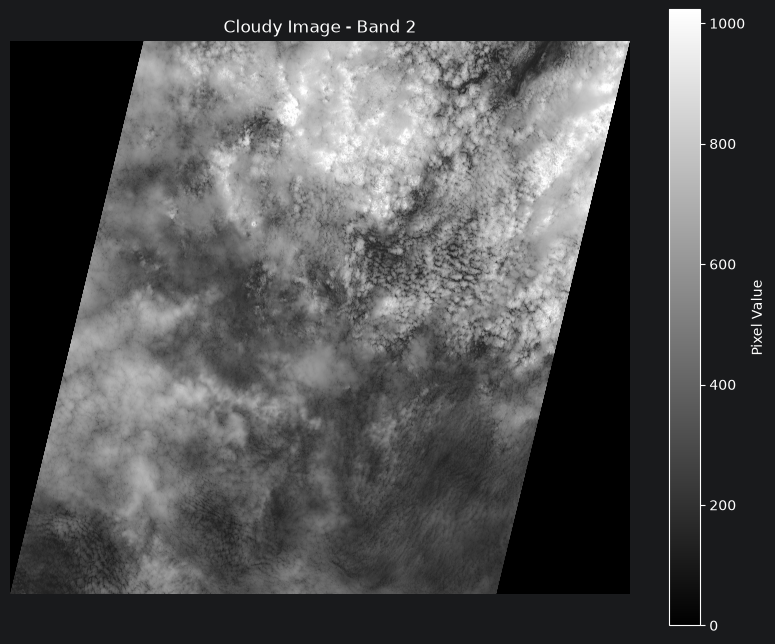

In [9]:
plt.figure(figsize=(10, 8))

plt.imshow(cloudy[0], cmap="gray")
plt.title("Cloudy Image - Band 2")
plt.axis("off")
plt.colorbar(label="Pixel Value")

plt.show()

## clear image

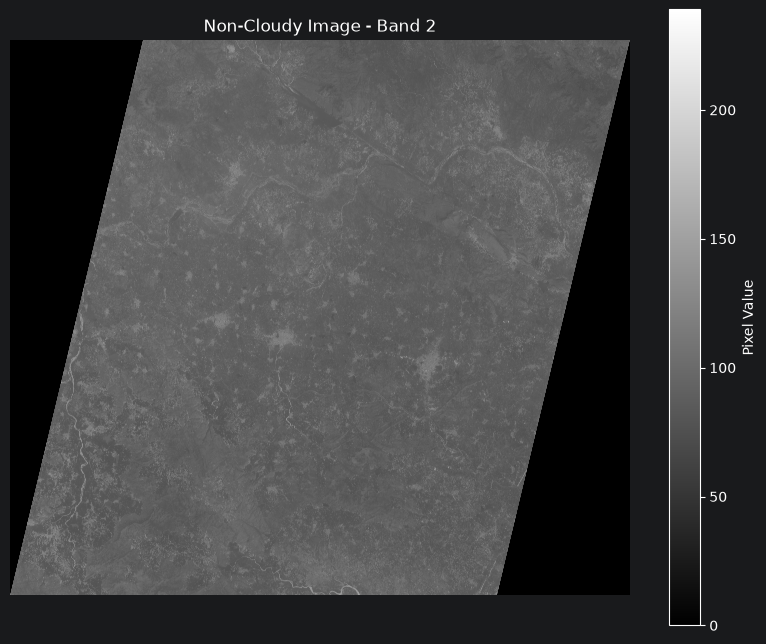

In [10]:
plt.figure(figsize=(10, 8))

plt.imshow(clear[0], cmap="gray")
plt.title("Non-Cloudy Image - Band 2")
plt.axis("off")
plt.colorbar(label="Pixel Value")

plt.show()

## compare alignment

In [12]:
from rasterio.transform import array_bounds

# Get geographic bounds
cloudy_bounds = array_bounds(
    cloudy.shape[1],
    cloudy.shape[2],
    cloudy_meta["transform"]
)

clear_bounds = array_bounds(
    clear.shape[1],
    clear.shape[2],
    clear_meta["transform"]
)

print("CLOUDY BOUNDS")
print("Left  :", cloudy_bounds[0])
print("Bottom:", cloudy_bounds[1])
print("Right :", cloudy_bounds[2])
print("Top   :", cloudy_bounds[3])

print("\nCLEAR BOUNDS")
print("Left  :", clear_bounds[0])
print("Bottom:", clear_bounds[1])
print("Right :", clear_bounds[2])
print("Top   :", clear_bounds[3])

# Calculate common geographic area
left   = max(cloudy_bounds[0], clear_bounds[0])
bottom = max(cloudy_bounds[1], clear_bounds[1])
right  = min(cloudy_bounds[2], clear_bounds[2])
top    = min(cloudy_bounds[3], clear_bounds[3])

print("\nCOMMON AREA")
print("Left  :", left)
print("Bottom:", bottom)
print("Right :", right)
print("Top   :", top)

if left < right and bottom < top:
    overlap_width = right - left
    overlap_height = top - bottom

    cloudy_area = (
        cloudy_bounds[2] - cloudy_bounds[0]
    ) * (
        cloudy_bounds[3] - cloudy_bounds[1]
    )

    clear_area = (
        clear_bounds[2] - clear_bounds[0]
    ) * (
        clear_bounds[3] - clear_bounds[1]
    )

    overlap_area = overlap_width * overlap_height

    print("\nOverlap width :", overlap_width, "meters")
    print("Overlap height:", overlap_height, "meters")
    print("Overlap area  :", overlap_area, "m²")

    print("\nCloudy overlap:", overlap_area / cloudy_area * 100, "%")
    print("Clear overlap :", overlap_area / clear_area * 100, "%")
else:
    print("\nERROR: Images do not overlap geographically.")

CLOUDY BOUNDS
Left  : 219203.94308370308
Bottom: 2045387.5
Right : 309853.94308370305
Top   : 2126272.5

CLEAR BOUNDS
Left  : 219198.94308370308
Bottom: 2045522.5
Right : 309683.94308370305
Top   : 2126517.5

COMMON AREA
Left  : 219203.94308370308
Bottom: 2045522.5
Right : 309683.94308370305
Top   : 2126272.5

Overlap width : 90479.99999999997 meters
Overlap height: 80750.0 meters
Overlap area  : 7306259999.999998 m²

Cloudy overlap: 99.64587489998347 %
Clear overlap : 99.6920031291614 %


## Pixel Grid Alignment

In [13]:

cloudy_transform = cloudy_meta["transform"]
clear_transform = clear_meta["transform"]

print("PIXEL GRID OFFSET")

x_offset = clear_transform.c - cloudy_transform.c
y_offset = clear_transform.f - cloudy_transform.f

print("X offset:", x_offset, "meters")
print("Y offset:", y_offset, "meters")

print("\nAt 5 m resolution:")

print("X offset:", x_offset / 5, "pixels")
print("Y offset:", y_offset / 5, "pixels")

PIXEL GRID OFFSET
X offset: -5.0 meters
Y offset: 245.0 meters

At 5 m resolution:
X offset: -1.0 pixels
Y offset: 49.0 pixels


## Estimated Cloud coverage

In [15]:
import numpy as np

# Use the cloudy Band 2
cloudy_band = cloudy[0]

# Ignore zero/background pixels
valid_pixels = cloudy_band > 0

# Basic statistics
valid_values = cloudy_band[valid_pixels]

print("CLOUDY IMAGE STATISTICS")
print("Valid pixels:", valid_pixels.sum())
print("Min:", valid_values.min())
print("Max:", valid_values.max())
print("Mean:", valid_values.mean())
print("Median:", np.median(valid_values))
print("Std:", valid_values.std())

CLOUDY IMAGE STATISTICS
Valid pixels: 230071723
Min: 106
Max: 1023
Mean: 479.58176650417835
Median: 462.0
Std: 190.70088052065304


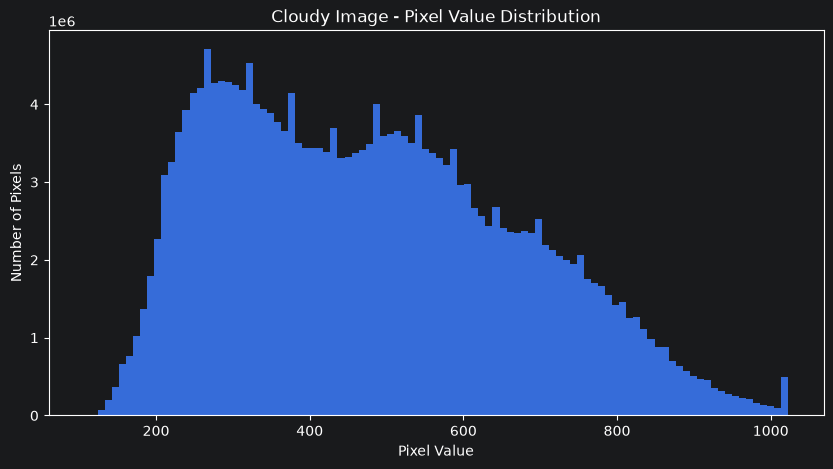

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(valid_values, bins=100)

plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels")
plt.title("Cloudy Image - Pixel Value Distribution")

plt.show()

## Test 256x256

===== PATCH INFORMATION =====
Cloudy patch shape: (256, 256)
Clear patch shape : (256, 256)

Valid pixel percentage:
Cloudy: 100.0 %
Clear: 100.0 %


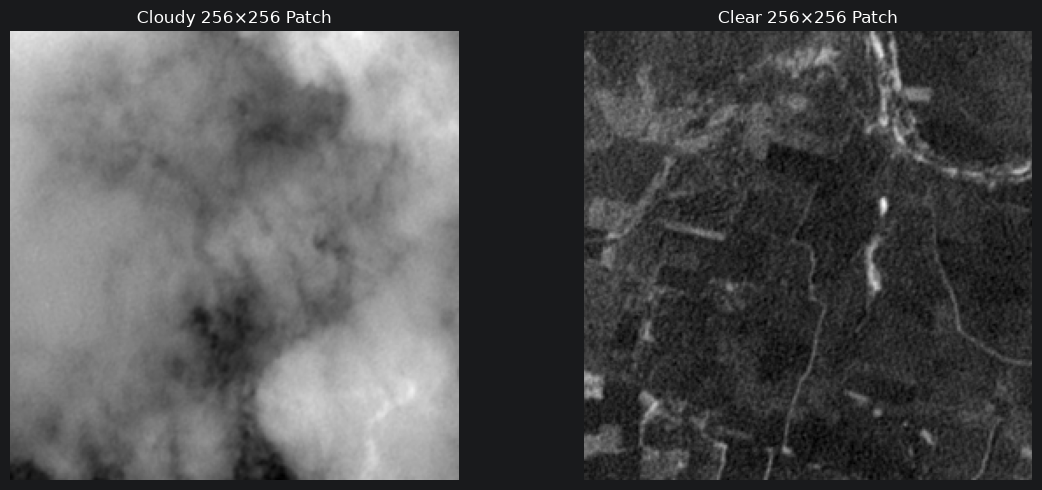

In [19]:
PATCH_SIZE = 256

# Find valid pixels
cloudy_valid = cloudy[0] > 0
clear_valid = clear[0] > 0

# Search for a valid patch near the center
cloudy_center_y = cloudy.shape[1] // 2
cloudy_center_x = cloudy.shape[2] // 2

clear_center_y = clear.shape[1] // 2
clear_center_x = clear.shape[2] // 2

half = PATCH_SIZE // 2

# Extract center patches
cloudy_patch = cloudy[
    0,
    cloudy_center_y - half:cloudy_center_y + half,
    cloudy_center_x - half:cloudy_center_x + half
]

clear_patch = clear[
    0,
    clear_center_y - half:clear_center_y + half,
    clear_center_x - half:clear_center_x + half
]

print("===== PATCH INFORMATION =====")
print("Cloudy patch shape:", cloudy_patch.shape)
print("Clear patch shape :", clear_patch.shape)

print("\nValid pixel percentage:")
print(
    "Cloudy:",
    np.mean(cloudy_patch > 0) * 100,
    "%"
)

print(
    "Clear:",
    np.mean(clear_patch > 0) * 100,
    "%"
)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cloudy_patch, cmap="gray")
axes[0].set_title("Cloudy 256×256 Patch")
axes[0].axis("off")

axes[1].imshow(clear_patch, cmap="gray")
axes[1].set_title("Clear 256×256 Patch")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Count Generated 256x256

In [20]:
PATCH_SIZE = 256
PIXEL_SIZE = 5  # meters per pixel

# Common overlap dimensions from Step 7
overlap_width_m = 90480
overlap_height_m = 80750

# Convert meters to pixels
overlap_width_px = int(overlap_width_m / PIXEL_SIZE)
overlap_height_px = int(overlap_height_m / PIXEL_SIZE)

# Number of complete 256x256 patches
patches_x = overlap_width_px // PATCH_SIZE
patches_y = overlap_height_px // PATCH_SIZE

total_patches = patches_x * patches_y

print("===== PATCH COUNT =====")

print("Common width :", overlap_width_px, "pixels")
print("Common height:", overlap_height_px, "pixels")

print("\n256×256 patches across:", patches_x)
print("256×256 patches down  :", patches_y)

print("\nTotal complete 256×256 patches:", total_patches)

# Remaining pixels that don't form a complete patch
remaining_x = overlap_width_px % PATCH_SIZE
remaining_y = overlap_height_px % PATCH_SIZE

print("\nUnused pixels:")
print("Width remainder :", remaining_x)
print("Height remainder:", remaining_y)

===== PATCH COUNT =====
Common width : 18096 pixels
Common height: 16150 pixels

256×256 patches across: 70
256×256 patches down  : 63

Total complete 256×256 patches: 4410

Unused pixels:
Width remainder : 176
Height remainder: 22


# Conclusion

- Cloudy and clear images have the same spatial resolution (5 m) and CRS (UTM Zone 44N).
- The images have approximately **99.7% geographic overlap**, so the pair is suitable for further processing.
- A small pixel-grid offset was observed (**1 pixel X, 49 pixels Y**), which will be handled during alignment.
- A **256×256** patch was successfully extracted from both images with 100% valid pixels.
- The common area can produce approximately **4,410 non-overlapping 256×256 patch pairs**.
- Overall, this pair is **suitable for the cloud-removal dataset** and can be kept for further preprocessing.